In [1]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.6 MB/s eta 0:00:0000:010:01

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
!pip install emoji


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import math
import os
import pandas as pd
import random 
import spacy
import re
import emoji
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from spacy.lang.en.stop_words import STOP_WORDS
import string

In [9]:
dataset_path = os.path.join('..', 'datasets', 'archive')

comments = pd.read_csv(
    os.path.join(dataset_path, 'UScomments.csv'),
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False
)
videos = pd.read_csv(
    os.path.join(dataset_path, 'USvideos.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

<h3>Coments dataset </h3> 

In [11]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


<h5>Change of the number of the column likes a likes_comment to not confuse with the likes of the video </h5>

In [12]:
comments=comments.rename(columns={'likes': 'likes_comment'})

In [13]:
comments.sample(3)

,video_id,comment_text,likes_comment,replies
439892,IcYbVguyp6w,What do you do with all the stuff that you make?,0,0
229767,1lOd7rDFYbc,Süper Cüte,0,0
192727,ofz2cHLkiRI,Didnt you like the hermes strap?,0,0


<h5>Change the type of data in the column likes how to return it</h5>

In [14]:
comments['likes_comment'] = pd.to_numeric(comments['likes_comment'],errors='coerce')
comments['replies'] = pd.to_numeric(comments['replies'],errors='coerce')

In [15]:
comments.info()
comments.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   video_id       691400 non-null  object 
 1   comment_text   691374 non-null  object 
 2   likes_comment  691399 non-null  float64
 3   replies        691399 non-null  float64
dtypes: float64(2), object(2)
memory usage: 21.1+ MB


,video_id,comment_text,likes_comment,replies
156625,OZAfse9Pb4c,What would happen if you didn't drink water,0.0,0.0
380399,KPqtlI3aJIE,Damn,0.0,0.0
209314,l7yxJDFvTRM,this is our generation we fucked up,0.0,0.0


<h5>Rows with null values ​​are checked and deleted</h5>

In [16]:
comments.isna().sum()

video_id          0
comment_text     26
likes_comment     1
replies           1
dtype: int64

In [17]:
comments = comments.dropna(axis='rows').reset_index(drop=True)

In [18]:
comments.isna().sum()

video_id         0
comment_text     0
likes_comment    0
replies          0
dtype: int64

In [19]:
comments.sample(3)

,video_id,comment_text,likes_comment,replies
601854,r_Vv6abqauM,Hell yeah,0.0,0.0
483014,AC83xjb5Njw,my sex is poor,1.0,0.0
108659,_pc1kON-doU,I cant be the only one knows that NO ONE in hi...,0.0,0.0


<h3>Videos dataset </h3> 

In [20]:
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7992 non-null   object 
 1   title           7992 non-null   object 
 2   channel_title   7992 non-null   object 
 3   category_id     7992 non-null   int64  
 4   tags            7992 non-null   object 
 5   views           7992 non-null   int64  
 6   likes           7992 non-null   int64  
 7   dislikes        7992 non-null   int64  
 8   comment_total   7992 non-null   int64  
 9   thumbnail_link  7992 non-null   object 
 10  date            7992 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 686.9+ KB


<h5>Change of the number of the column likes a likes_video to not confuse with the likes of the comment </h5>

In [21]:
videos=videos.rename(columns={'likes': 'likes_video'})

In [22]:
videos.sample(3)

,video_id,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date
5333,ORSMs7lZtdY,Did The Las Vegas Gunman Act Alone?,CBS Los Angeles,25,CBS 2 News Evening|Las Vegas Shooting,94339,221,76,503,https://i.ytimg.com/vi/ORSMs7lZtdY/default.jpg,9.10
3504,xwW0VfkFljE,Woman Removed From Plane After Claiming She Wa...,Inside Edition,25,Animals|inside edition newsdesk|dogs|remove|se...,145269,2692,118,1250,https://i.ytimg.com/vi/xwW0VfkFljE/default.jpg,30.09
3541,BNJUsE7pEs4,Hansen Unplugged: Anthem protests not about di...,WFAA,25,[none],746524,18435,2025,2447,https://i.ytimg.com/vi/BNJUsE7pEs4/default.jpg,30.09


<h5>The date column is only formatted dd:mm, a default year (2025) was added to be able to change the data type and perform temporal analysis.</h5>

In [23]:
videos['date'] = videos['date'].astype(str) + '.2025'
videos['date'] = pd.to_datetime(videos['date'], format='%d.%m.%Y')

videos['year'] = videos['date'].dt.year
videos['month'] = videos['date'].dt.month
videos['day'] = videos['date'].dt.day

In [24]:
videos.sample(3)

,video_id,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day
3145,ktmcO3lVuPc,Gregg Popovich slams Trump and white privilege,CorkGaines,22,[none],11993,95,74,149,https://i.ytimg.com/vi/ktmcO3lVuPc/default.jpg,2025-09-28,2025,9,28
3917,lSsTCiC93WI,Green Lantern - Nostalgia Critic,Channel Awesome,24,channel awesome|nostalgia critic|doug walker|m...,827684,27898,1504,5656,https://i.ytimg.com/vi/lSsTCiC93WI/default.jpg,2025-01-02,2025,1,2
1117,YrTKLZi6rqk,GET READY WITH ME! - ft. old friend,Madeyewlook,26,Halloween|makeup tutorial|body painting|hallow...,140678,9064,43,174,https://i.ytimg.com/vi/YrTKLZi6rqk/default.jpg,2025-09-18,2025,9,18


In [25]:
videos.isna().sum()

video_id          0
title             0
channel_title     0
category_id       0
tags              0
views             0
likes_video       0
dislikes          0
comment_total     0
thumbnail_link    0
date              0
year              0
month             0
day               0
dtype: int64

<h3>Merged Dataset df</h3>

<h5>The two datasets are combined using videos_id as a common column.</h5>

In [26]:
df = pd.merge(comments, videos, on='video_id')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940799 entries, 0 to 2940798
Data columns (total 17 columns):
 #   Column          Dtype         
---  ------          -----         
 0   video_id        object        
 1   comment_text    object        
 2   likes_comment   float64       
 3   replies         float64       
 4   title           object        
 5   channel_title   object        
 6   category_id     int64         
 7   tags            object        
 8   views           int64         
 9   likes_video     int64         
 10  dislikes        int64         
 11  comment_total   int64         
 12  thumbnail_link  object        
 13  date            datetime64[ns]
 14  year            int32         
 15  month           int32         
 16  day             int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(5), object(6)
memory usage: 347.8+ MB


In [28]:
df.sample(3)

,video_id,comment_text,likes_comment,replies,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day
1912207,CwLGro-dFWg,So bad👎 You could write better lyrics... I hop...,0.0,0.0,Charlie Puth – How Long [Official Audio],Charlie Puth,10,charlie puth|voicenotes|how long|charlie puth ...,2177310,156180,1011,13217,https://i.ytimg.com/vi/CwLGro-dFWg/default.jpg,2025-01-08,2025,1,8
622233,Z-LmHjkN2EU,Sad that people can be so dumb.\nAll they had ...,0.0,0.0,Xov xwm-ເຂື່ອນນໍ້າອ້າວ( nam ao dam ) tawg txau...,Xov Xwm_Lom Zem,22,xov xwm|xov xwm nplog teb|tsom xyooj|laib laus...,926059,2339,108,731,https://i.ytimg.com/vi/Z-LmHjkN2EU/default.jpg,2025-09-21,2025,9,21
836462,12vfxYs6F7E,Learn how to flick bottle caps,0.0,0.0,This Week I Learned to Blacksmith with Alec St...,Mike Boyd,24,mike boyd|learn quick|alec steele|steel|alex|s...,329124,15047,118,1803,https://i.ytimg.com/vi/12vfxYs6F7E/default.jpg,2025-09-26,2025,9,26


<h3>EDA</h3>

<h5>Videos were analyzed by day since the dataset only contains two months (January and September)</h5>

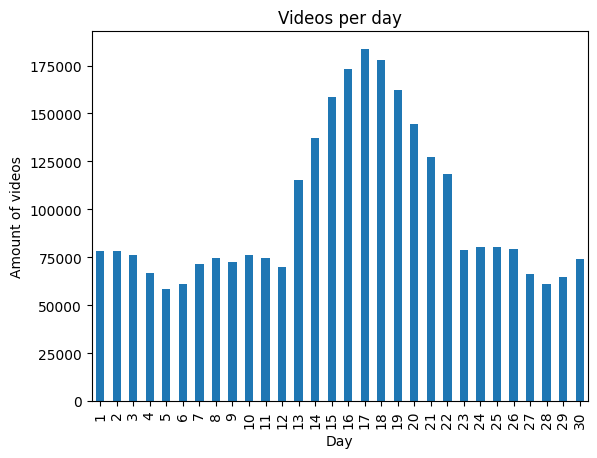

In [29]:
df['day'].value_counts().sort_index().plot(kind='bar', title='Videos per day')
plt.xlabel('Day')
plt.ylabel('Amount of videos')
plt.show()


<h5>Top comments with the most likes</h5>

In [30]:
top_comentarios = df.sort_values(by='likes_comment', ascending=False).head(10)
display(top_comentarios[['comment_text', 'likes_comment', 'video_id']])

,comment_text,likes_comment,video_id
701407,What if Mable was the duck??,48772.0,0R7MQwmbiQc
701406,What if Mable was the duck??,48772.0,0R7MQwmbiQc
701405,What if Mable was the duck??,48772.0,0R7MQwmbiQc
701404,What if Mable was the duck??,48772.0,0R7MQwmbiQc
631784,What if Mable was the duck??,47785.0,0R7MQwmbiQc
631781,What if Mable was the duck??,47785.0,0R7MQwmbiQc
631782,What if Mable was the duck??,47785.0,0R7MQwmbiQc
631783,What if Mable was the duck??,47785.0,0R7MQwmbiQc
536520,What if Mable was the duck??,45316.0,0R7MQwmbiQc
536517,What if Mable was the duck??,45316.0,0R7MQwmbiQc


<h5>Top videos with the most likes</h5>

In [31]:
top_comments_video = df.sort_values(by='likes_video', ascending=False).head(10)
display(top_comments_video[['comment_text', 'likes_video', 'video_id']])

,comment_text,likes_video,video_id
698389,l like the song,2010366,MBdVXkSdhwU
442344,_just made another 2 accounts to stream for 1 ...,2010366,MBdVXkSdhwU
442332,ARMYS lets reach to at least 21M views.Our boy...,2010366,MBdVXkSdhwU
698373,Oh man Holy shiteuuuu😂.......2M likes mannnnn🎉...,2010366,MBdVXkSdhwU
534389,"Iam dead with the dance ADN,so talent and crea...",2010366,MBdVXkSdhwU
698625,2m likes 😭😭💖,2010366,MBdVXkSdhwU
442336,"20 hours, now it's 20.5M views.❤️👌💯\nIn our co...",2010366,MBdVXkSdhwU
629017,#DNA38M in 3days and 6Hrs 😍,2010366,MBdVXkSdhwU
534393,i just got a bts ad on a bts music video....,2010366,MBdVXkSdhwU
698377,Let's keep up the good work ARMY :) Teamwork m...,2010366,MBdVXkSdhwU


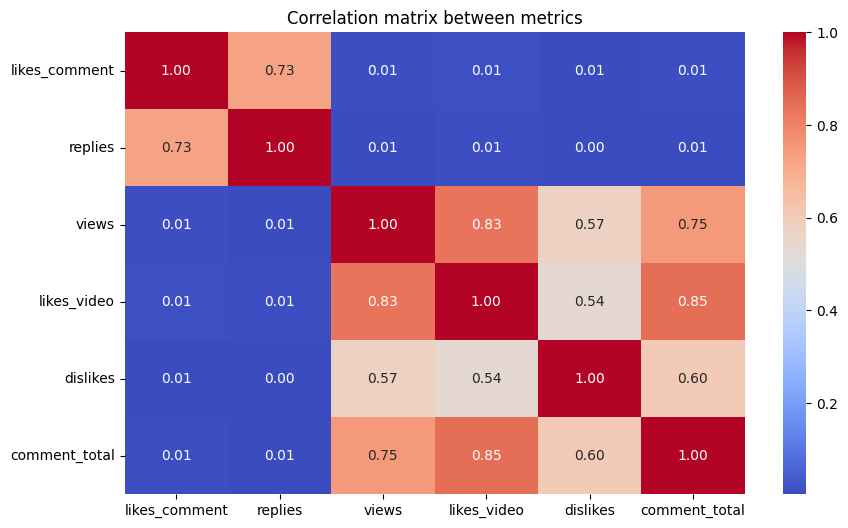

In [32]:
num_cols = ['likes_comment', 'replies', 'views', 'likes_video', 'dislikes', 'comment_total']
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix between metrics')
plt.show()

<li>There is a particularly strong correlation between "comment_likes" and "replies" (0.72), suggesting that comments with many "likes" tend to generate more replies.</li>

<li>The correlations with "views" are very low (0.01), indicating that the number of views is not strongly related to comment likes.</li>

<li>Comment engagement (likes and replies) is correlated.</li>



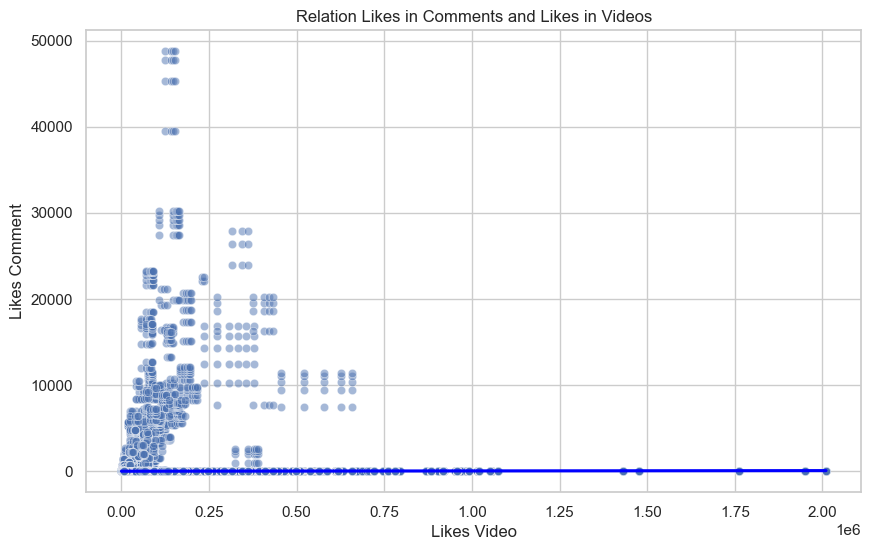

In [33]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
scatter1 = sns.scatterplot(data=df, x='likes_video', y='likes_comment', alpha=0.5)
sns.regplot(df, x='likes_video', y='likes_comment', scatter=False, color='blue')
plt.title('Relation Likes in Comments and Likes in Videos')
plt.xlabel('Likes Video')
plt.ylabel('Likes Comment')
plt.show()

<li>Low ratios (around 1) suggest videos with similar numbers of likes and dislikes, indicating content that generates mixed opinions.</li>

<li> The few videos with high ratios (>50) represent content with almost exclusively likes and very few dislike</li>>

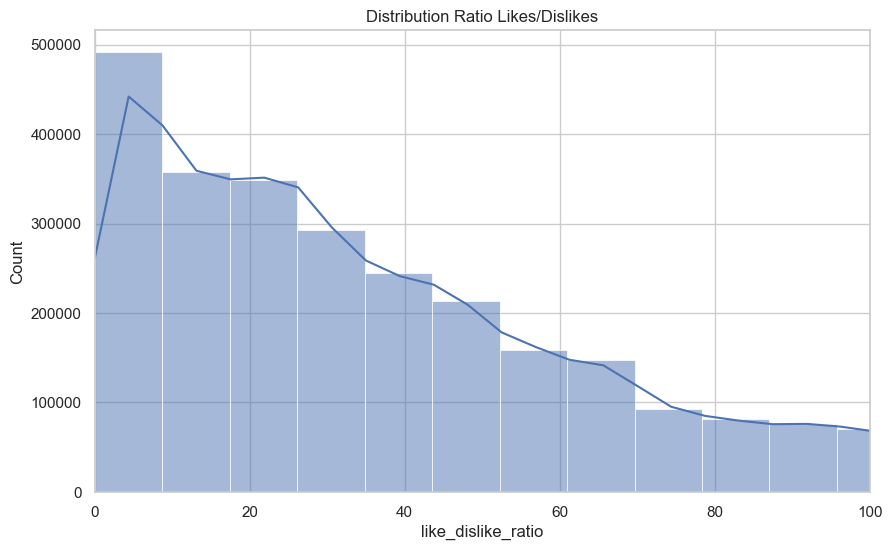

In [34]:
# ratio
df['like_dislike_ratio'] = df['likes_video'] / (df['dislikes'] + 1)  

plt.figure(figsize=(10, 6))
sns.histplot(df['like_dislike_ratio'], bins=100, kde=True)
plt.xlim(0, 100)  
plt.title('Distribution Ratio Likes/Dislikes')
plt.show()

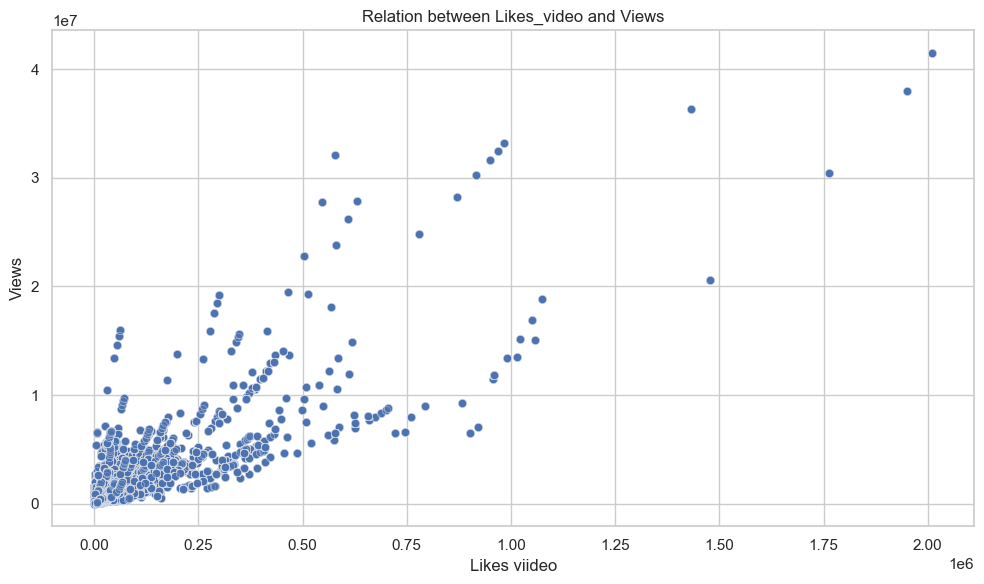

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='likes_video', y='views', alpha=0.3)

plt.title('Relation between Likes_video and Views')
plt.xlabel('Likes viideo')
plt.ylabel('Views')
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/c3/gd7dympn2rq3xs5m82fgbzz80000gn/T/ipykernel_31207/1235844677.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Tipo de Feedback', y='Cantidad', palette='Set2')


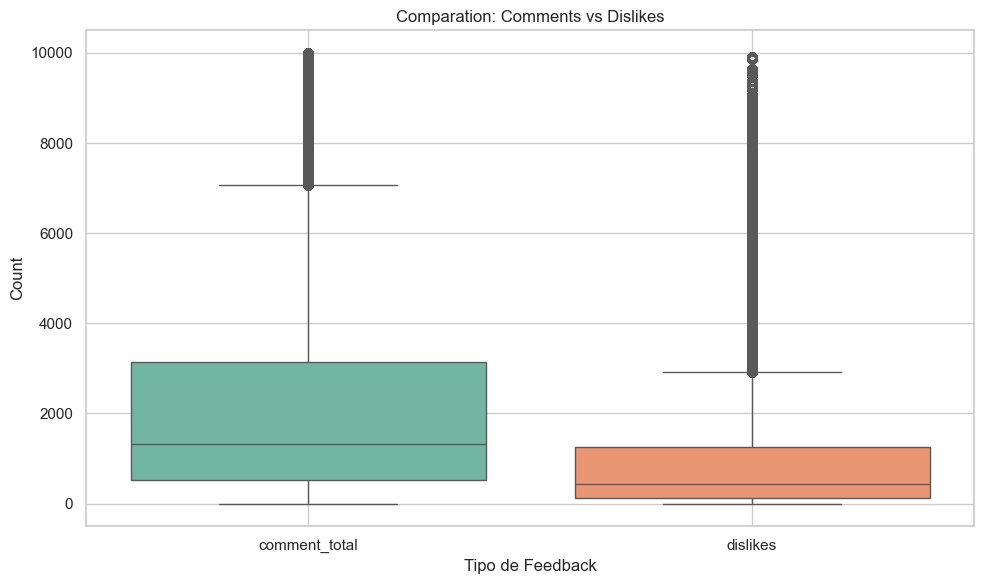

In [36]:
df_melted = pd.melt(df, value_vars=['comment_total', 'dislikes'], 
                    var_name='Tipo de Feedback', value_name='Cantidad')

df_melted = df_melted[df_melted['Cantidad'] < 10000]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Tipo de Feedback', y='Cantidad', palette='Set2')

plt.title('Comparation: Comments vs Dislikes')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

<h3>Machine learning for text</h3>

<h3>Text preprocessing (cleaning, lemmatization, stopword removal, and punctuation)</h3>

In [37]:
# lowercase
df['comment_text'] = df['comment_text'].str.lower()

<h5>Function to remove URLs, @user mentions and emojis</h5>

In [38]:
# Clean text
def clean_text(text):
    # URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # mentions @usuario
    text = re.sub(r'@\w+', '', text)
    # Emojis no ASCII
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub('r"[^\w\s]', '', text)
    return text

df['comment_text'] = df['comment_text'].apply(clean_text)

In [39]:
df.sample(3)

,video_id,comment_text,likes_comment,replies,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day,like_dislike_ratio
1377193,OLTXWUWcwOo,"extremely handsome and very humble young man, ...",0.0,0.0,Queen Sugar Star Kofi Siriboe!,Wendy Williams,24,queen sugar|oprah|wendy williams|the wendy wil...,175885,3750,111,1131,https://i.ytimg.com/vi/OLTXWUWcwOo/default.jpg,2025-09-29,2025,9,29,33.482143
2753181,DeTu8xSGpEM,chance verse starts @ 3:10...for the culture,0.0,0.0,John Legend - Penthouse Floor ft. Chance the R...,johnlegendVEVO,10,Columbia|John Legend feat. Chance the Rapper|P...,2139992,49078,1882,1709,https://i.ytimg.com/vi/DeTu8xSGpEM/default.jpg,2025-01-18,2025,1,18,26.063728
2506835,xbBMVa2A68s,the allergy argument was missed.,1.0,0.0,Cat vs Dog - Best Support Class,TierZoo,20,cat|dog|cute|gaming|overwatch|runescape|osrs,370320,21325,694,5356,https://i.ytimg.com/vi/xbBMVa2A68s/default.jpg,2025-01-20,2025,1,20,30.683453


<h5>Remove punctuation marks and stopwords</h5>

In [40]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])

stopwords = nlp.Defaults.stop_words

<div class="alert alert-block alert">
<b>Eli's Recommendation</b> <a class="tocSkip"></a>

Hey! Just to let you know, the code below that creates the final text column can take a long time to run, especially on larger datasets. Since it loops through everything, it can be pretty tough on your computer (and anyone else trying to run this notebook). I recommend using the code below instead, it speeds things up a lot and gives you the same results:

```python
def spacy_token_filter(doc):
    return " ".join(
        token.lemma_ for token in doc
        if token.text.lower() not in stopwords and not token.is_punct
    )

df["final_text"] = [
    spacy_token_filter(doc) for doc in nlp.pipe(
        df["comment_text"],
        batch_size=1000,
        n_process=-1
    )
]

In [46]:
def spacy_token_filter(doc):
    return " ".join([
        token.lemma_  #Convert each word to its base form (lemma)
        for token in doc # We iterate over the spaCy `Doc` object (comment already processed) 
        if token.text not in stopwords and not token.is_punct # Remove stopwords 
    ])

texts = list(nlp.pipe(df['comment_text'], batch_size=1000, n_process=-1))  
df["final_text"] = [spacy_token_filter(doc) for doc in texts]

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/betaknight/april_code_pudding/youtube_sentiment_analysis/sentiment_venv/lib/python3.11/site-packages/spacy/__init__.py", line 6, in <module>
    from .errors import setup_default_warnings
  File "/Users/betaknight/april_code_pudding/youtube_sentiment_analysis/sentiment_venv/lib/python3.11/site-packages/spacy/errors.py", line 3, in <module>
    from .compat import Literal
  File "/Users/betaknight/april_code_pudding/youtube

KeyboardInterrupt: 

<h5>Raw comments ─► nlp.pipe (processed batch) ─► spaCy Doc ─► lemmas without stopwords/punctuation ─► Final clean text</h5>

In [42]:
df.sample(3)

,video_id,comment_text,likes_comment,replies,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day,like_dislike_ratio,final_text
331322,V-_HM2bRa0E,you are so talented craig show of your voice w...,0.0,0.0,Craig David - Heartline (Audio),CraigDavidVEVO,10,Craig David|Dance|Heartline|Speakerbox/Insanit...,52752,2410,37,201,https://i.ytimg.com/vi/V-_HM2bRa0E/default.jpg,2025-09-17,2025,9,17,63.421053,talented craig voice u capital fm litt rap gri...
486786,Uc32z-wgxU4,i want more,0.0,0.0,Game of Thrones Conquest & Rebellion: An Anima...,GameofThrones,1,[none],1570276,48988,338,2222,https://i.ytimg.com/vi/Uc32z-wgxU4/default.jpg,2025-09-17,2025,9,17,144.507375,want
1168317,ofz2cHLkiRI,i like the white wireless charger more,0.0,0.0,iPhone 8 + Apple Watch Series 3 Accessories,iJustine,22,ijustine|iphone 8|iphone 8 unboxing|apple watc...,707087,20543,1653,1909,https://i.ytimg.com/vi/ofz2cHLkiRI/default.jpg,2025-09-26,2025,9,26,12.420193,like white wireless charger


<h3> TF-IDF (Term Frequency-Inverse Document Frequency) </h3>

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [44]:
# Crear vectorizador
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))  

# Ajustar y transformar los datos
X = tfidf.fit_transform(df["final_text"])